In [4]:
import ipdb
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import cartopy
import cartopy.crs as ccrs
from endgame import hist2d
from eod import msg
import datetime
import glob
import os
from scipy.stats import binned_statistic_2d
from scipy import stats
import pickle as pkl
from scipy.stats import gaussian_kde, linregress
import importlib
from utils import u_statistics as u_stats
from COCOON import shear_scaling_plots
importlib.reload(shear_scaling_plots)
from GLOBAL import glob_util

%matplotlib inline

In [3]:
cd ..

/users/global/cornkle/pythonWorkspace/proj_CEH


In [5]:
REGIONS = glob_util.REGIONS

In [7]:
TABLE_PATH = '/prj/global_water/MCS_5000km2_tables_v3/base_tables_tir-prcp/'
dics = {}

for reg in REGIONS.keys():

    dfs = []

    for y in range(2000, 2021):

        files = glob.glob(
            f"{TABLE_PATH}/{reg}/{y}*.parquet"
        )

        if len(files) == 0:
            #print(reg, y, "not found")
            continue

        #print("Reading", files[0])

        df = pd.read_parquet(files[0])

        dfs.append(df)

    if len(dfs) == 0:
        #print(reg, "has no files")
        continue

    dics[reg] = pd.concat(dfs, ignore_index=True)

    print(reg, len(dics[reg]))

GPlains 253494
Eur 172201
china 308143
india 984179
WAf 41913
australia 5556
SAf 7036


In [8]:
print(list(dics['WAf'].keys()))

['date', 'month', 'hour', 'minute', 'year', 'day', 'area', 'area70', 'area60', 'area50', 'minlon', 'minlat', 'maxlon', 'maxlat', 'clon', 'clat', 'tminlon', 'tminlat', 'tmin', 'tmean', 'tp1', 'tp99', 'stormID', 'shape_complexity', 'major_axis_km', 'minor_axis_km', 'aspect_ratio', 'precipitation_mean', 'precipitation_max', 'precipitation_p80', 'precipitation_p90', 'precipitation_p95', 'precipitation_p99', 'precipitation_area1mm', 'precipitation_area3mm', 'precipitation_area8mm', 'region']


In [33]:
print(list(np.unique(dics['india']['hour'])))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


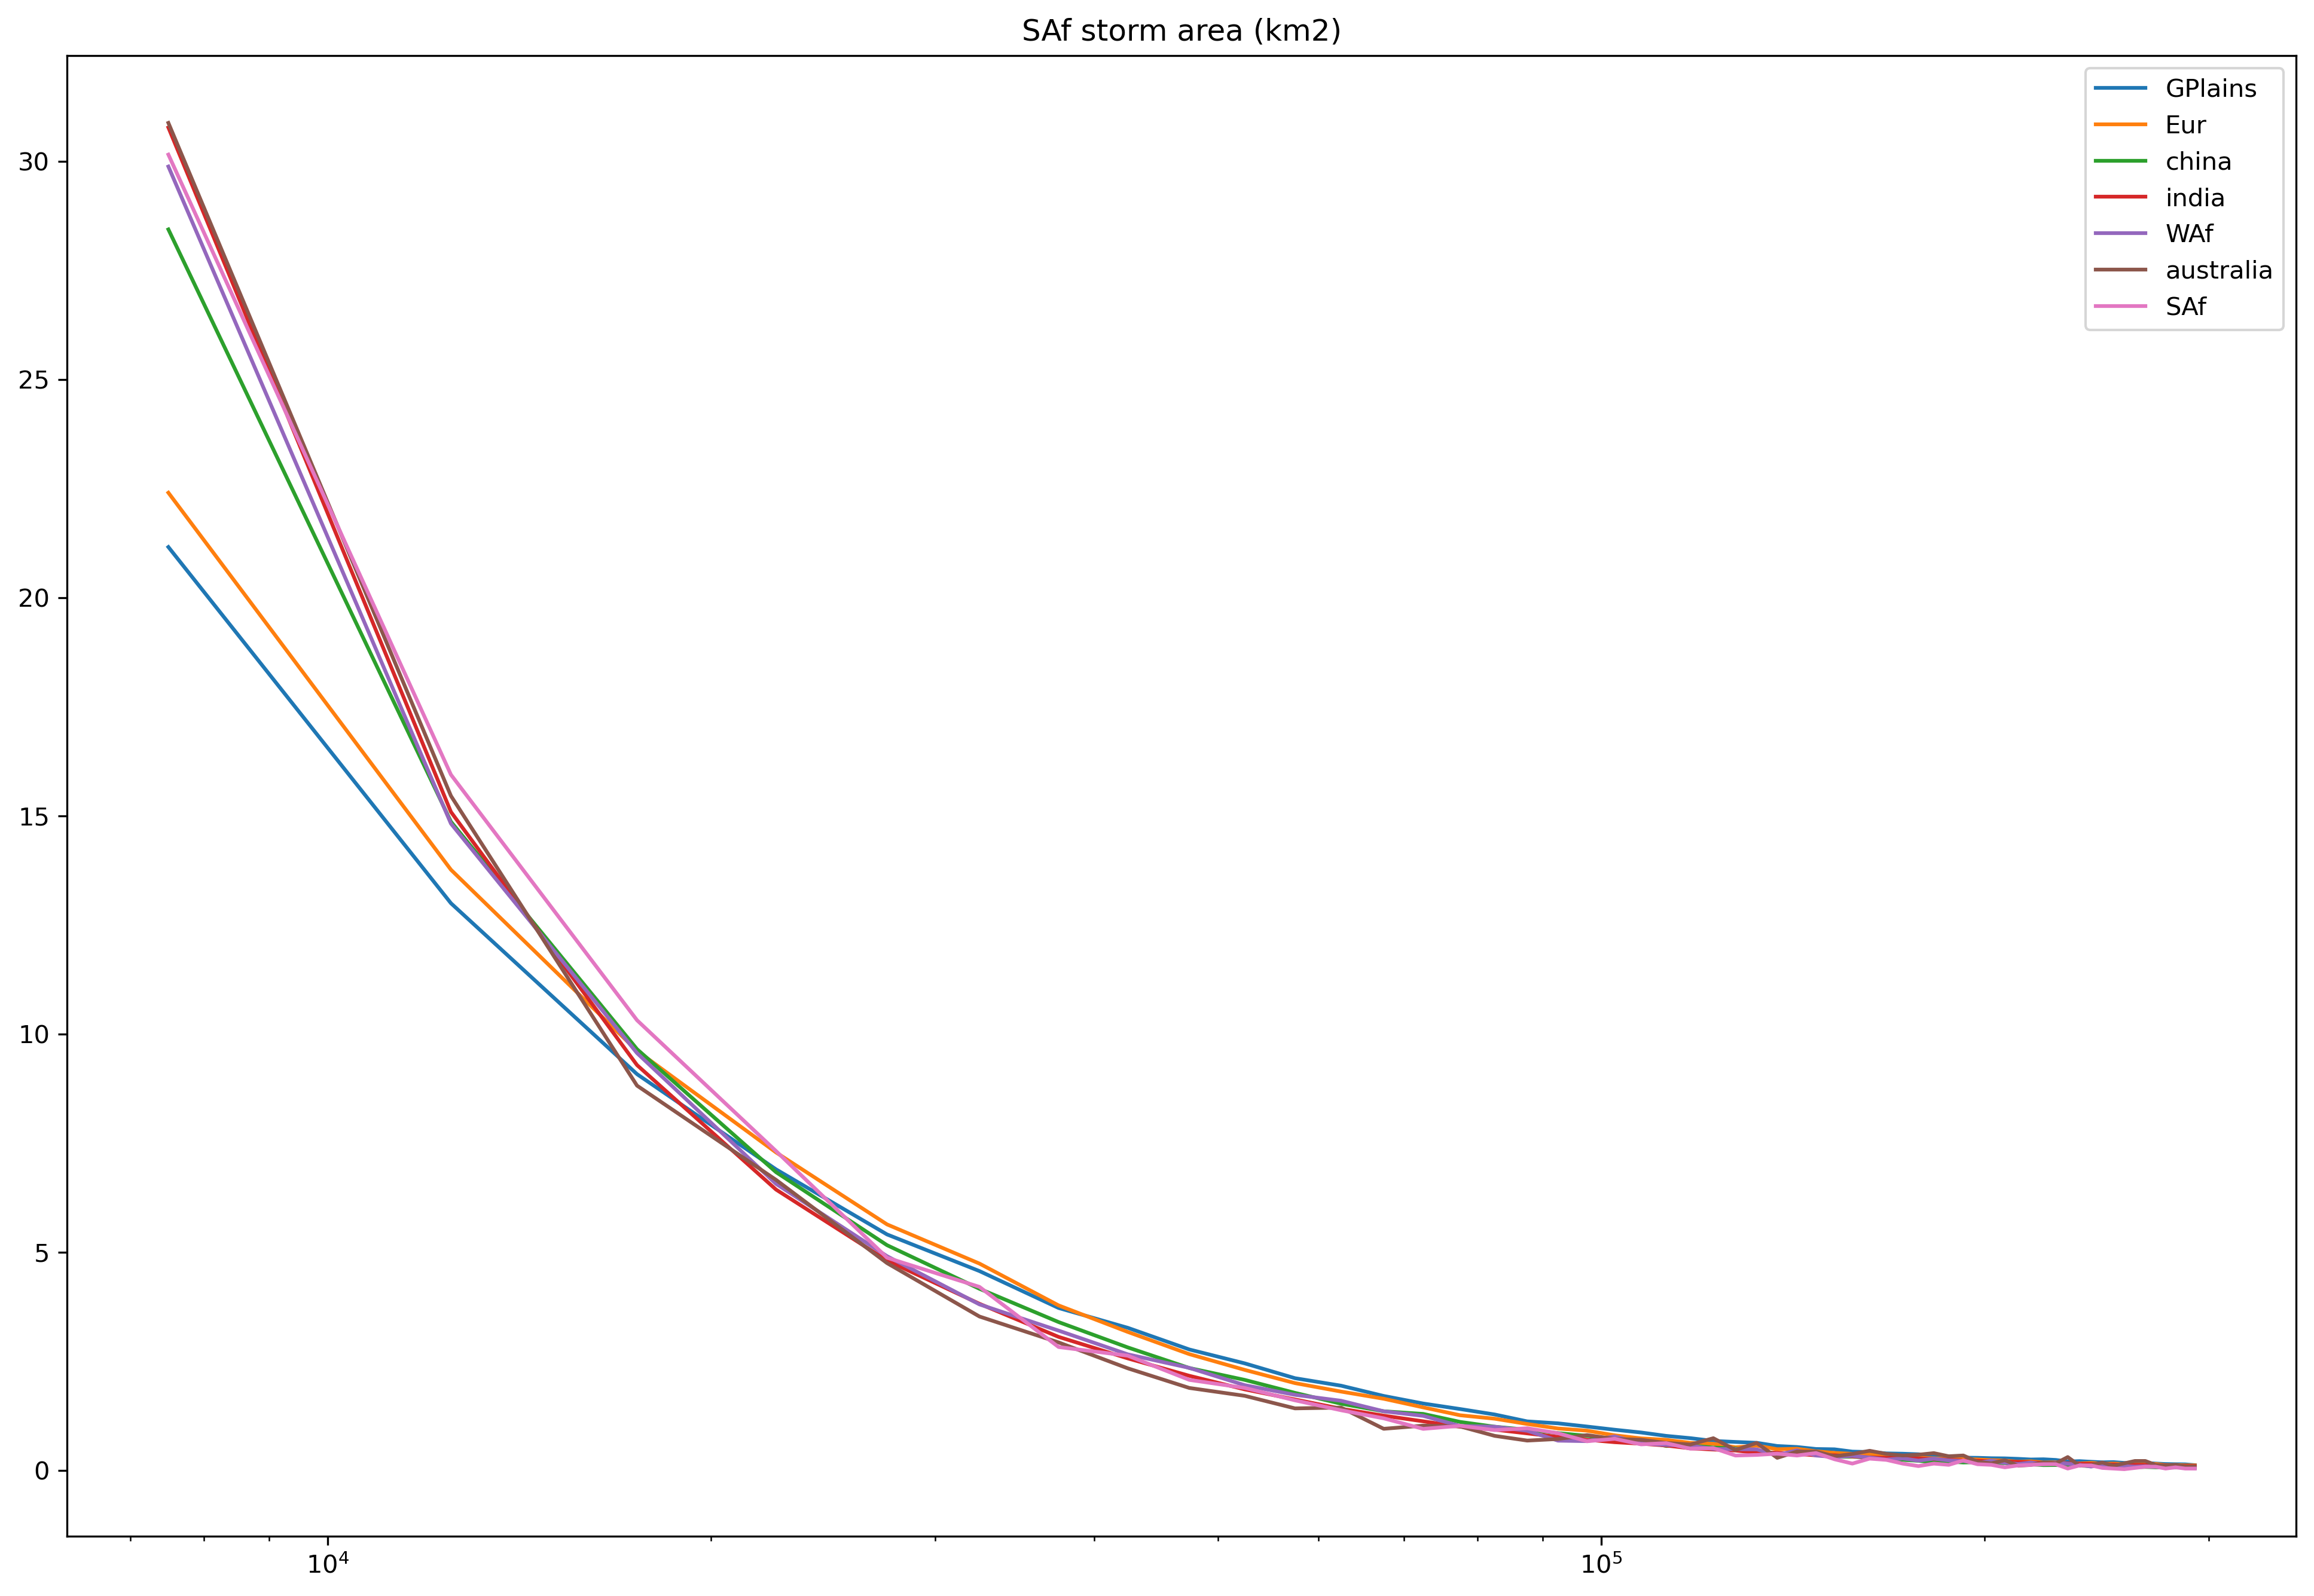

In [14]:
f= plt.figure(figsize=(13,9), dpi=300)

ax = f.add_subplot(111)
for ids, regs in enumerate(dics.keys()):

    pick = dics[regs]
    
    hist_freq, hist_count, bin_edge = u_stats.histo_frequency(pick['area'], bins=np.arange(5000,300000,5000))
    mid_bin = bin_edge[0:-1] + (bin_edge[1::]-bin_edge[0:-1])/2
    ax.plot(mid_bin,hist_freq, label= regs)

plt.legend()
ax.set_title(regs+' storm area (km2)')
plt.xscale('log')

plt.tight_layout()
#f.savefig(cnst.FIGS+'/LMCS/trackVSsnapshot/australia_trackVSsnapshot_area_histo.jpg')

GPlains 1.0000245571136475
Eur 1.0
china 1.0000722408294678
india 1.0
WAf 1.0003453493118286
australia 1.0088692903518677
SAf 1.0005537271499634


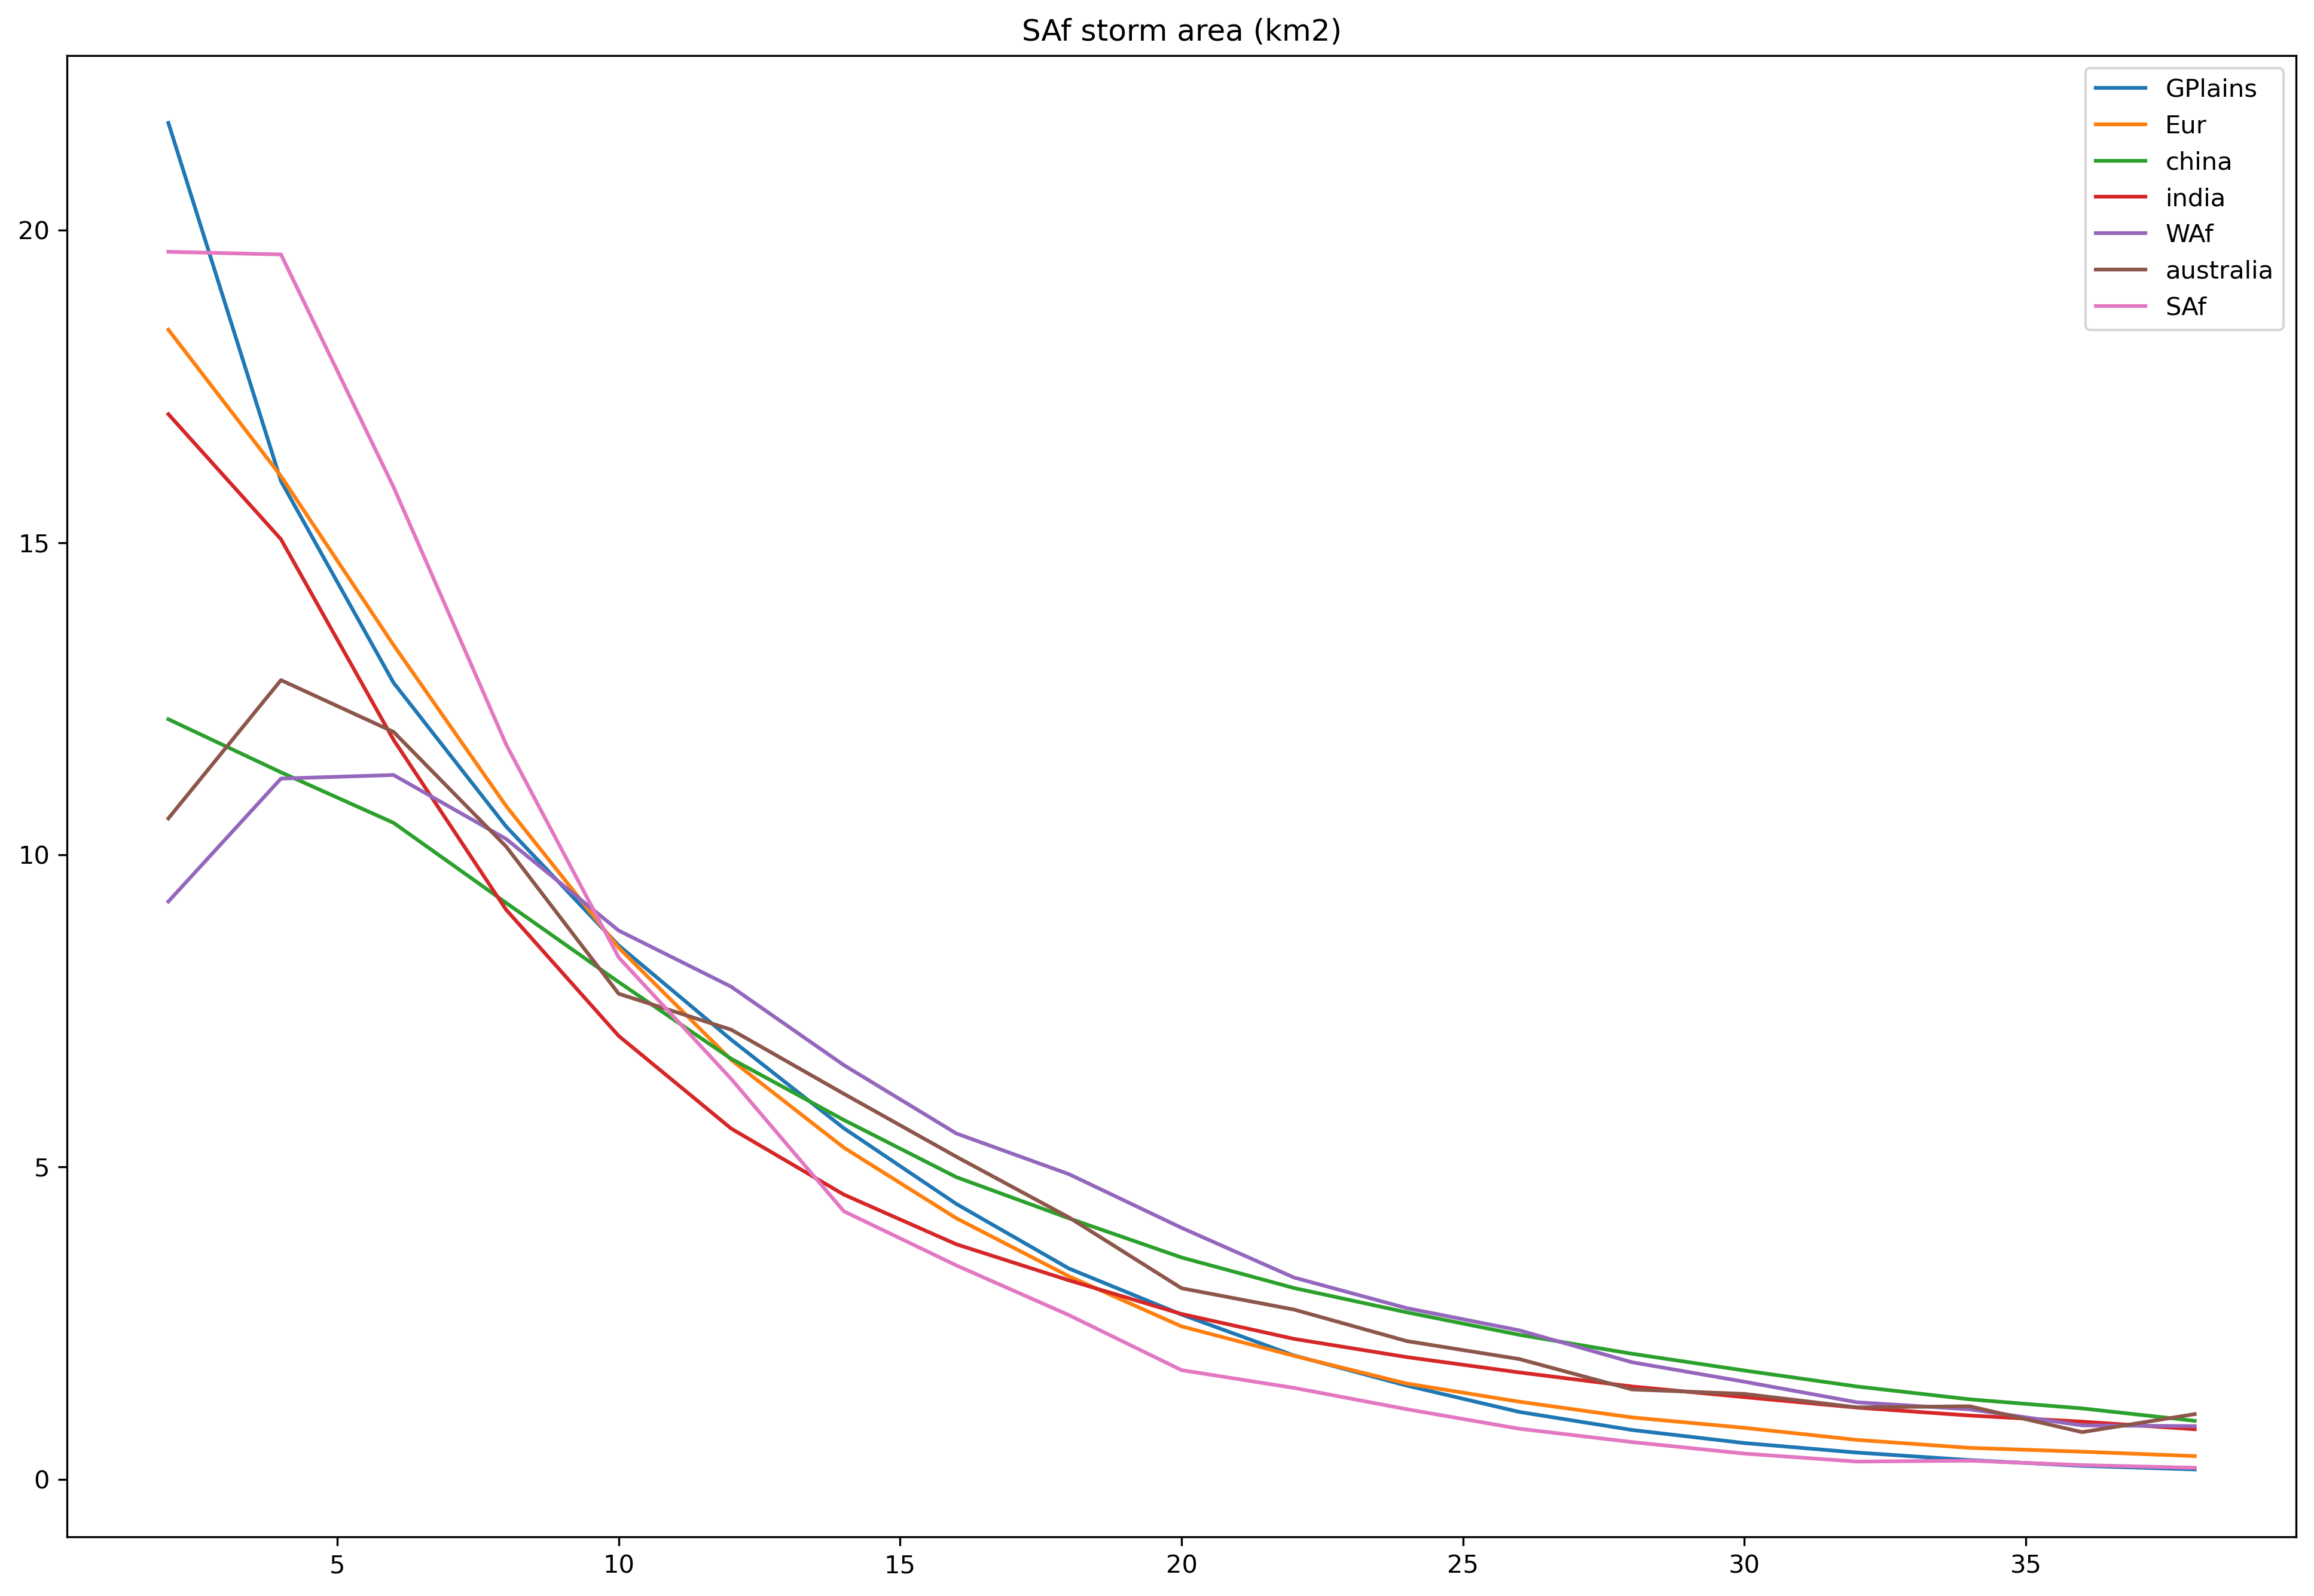

In [25]:
f= plt.figure(figsize=(13,9), dpi=300)

ax = f.add_subplot(111)
for ids, regs in enumerate(dics.keys()):

    pick = dics[regs]
    
    hist_freq, hist_count, bin_edge = u_stats.histo_frequency(pick['precipitation_max'], bins=np.arange(1,40,2))
    mid_bin = bin_edge[0:-1] + (bin_edge[1::]-bin_edge[0:-1])/2
    ax.plot(mid_bin,hist_freq, label= regs)

    print(regs,pick['precipitation_max'].min())

plt.legend()
ax.set_title(regs+' storm area (km2)')
#plt.xscale('log')

plt.tight_layout()
#f.savefig(cnst.FIGS+'/LMCS/trackVSsnapshot/australia_trackVSsnapshot_area_histo.jpg')

GPlains -82.11373901367188
Eur -74.13250732421875
china -94.14999389648438
india -112.93296813964844
WAf -86.7744140625
australia -95.75437927246094
SAf -86.88330078125


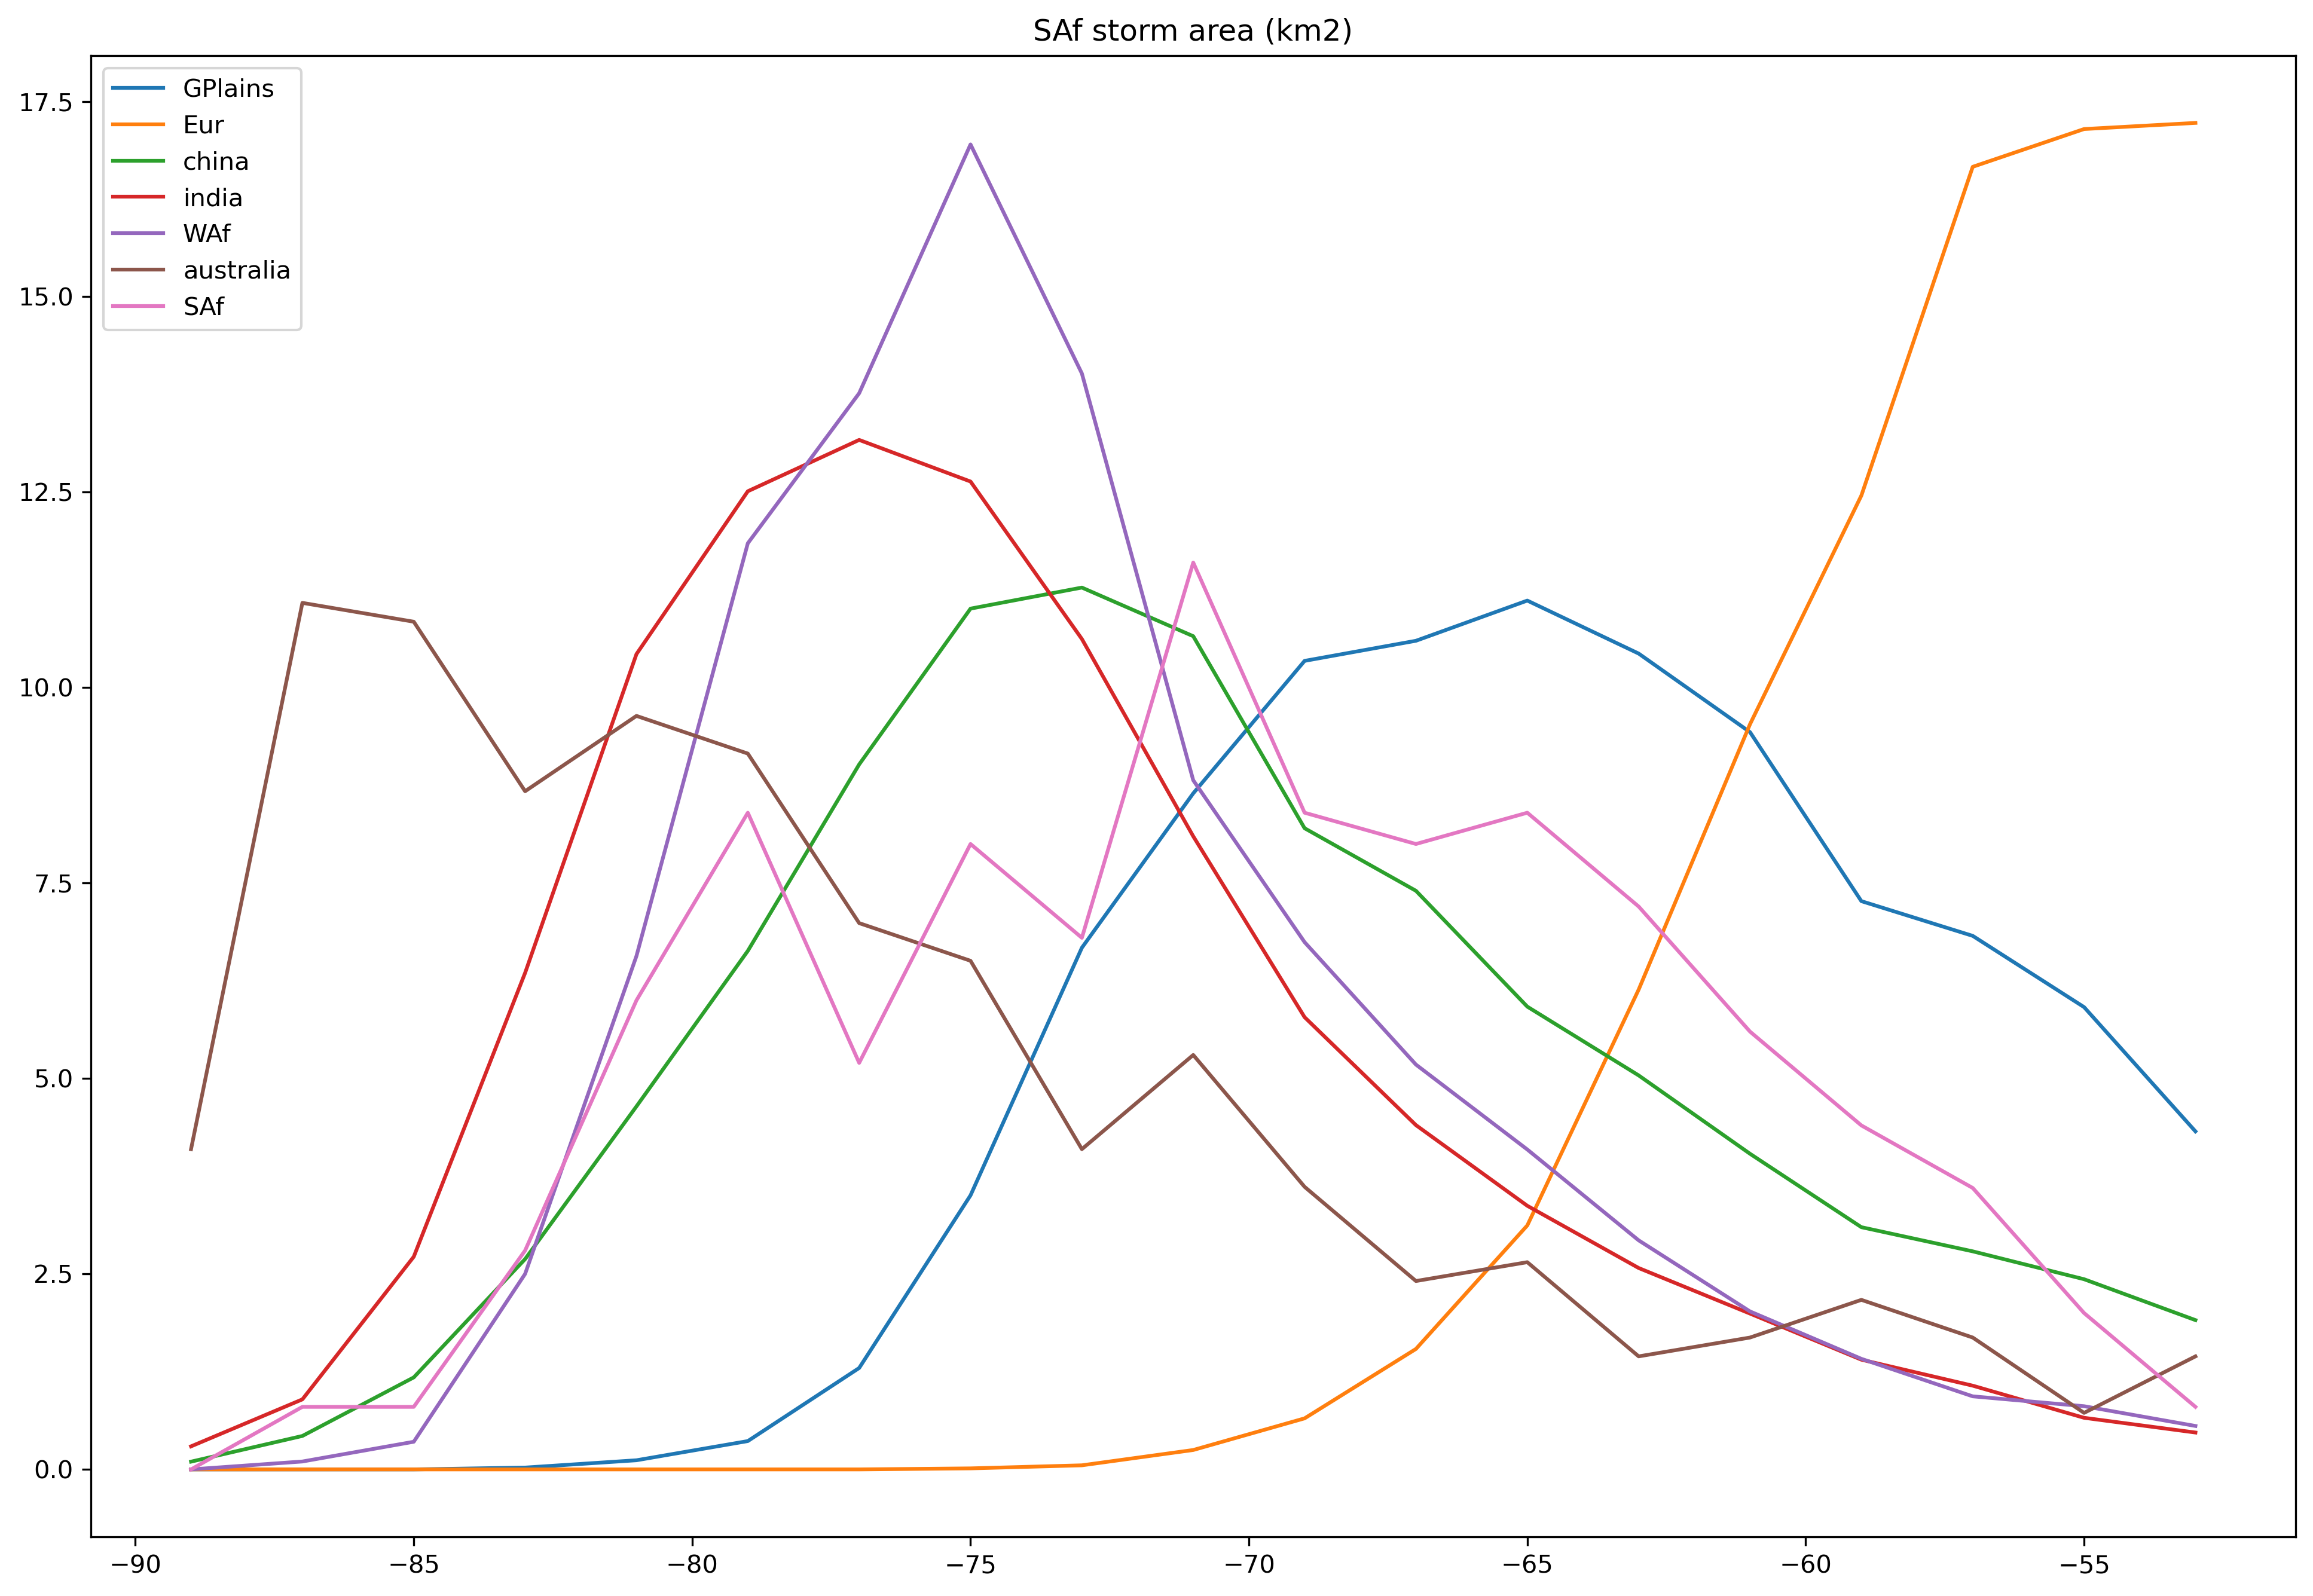

In [38]:
f= plt.figure(figsize=(13,9), dpi=300)

ax = f.add_subplot(111)
for ids, regs in enumerate(dics.keys()):

    pick = dics[regs]
    utc_offset = REGIONS[regs][2]
    
    lt_hour = (pick["hour"] + utc_offset) % 24

    pick = pick[
        (lt_hour >= 15) &
        (lt_hour <= 21) & (pick['precipitation_max']>20)
    ]
    
    hist_freq, hist_count, bin_edge = u_stats.histo_frequency(pick['tmin'], bins=np.arange(-90,-50,2))
    mid_bin = bin_edge[0:-1] + (bin_edge[1::]-bin_edge[0:-1])/2
    ax.plot(mid_bin,hist_freq, label= regs)

    print(regs,pick['tmin'].min())

plt.legend()
ax.set_title(regs+' storm area (km2)')
#plt.xscale('log')

plt.tight_layout()

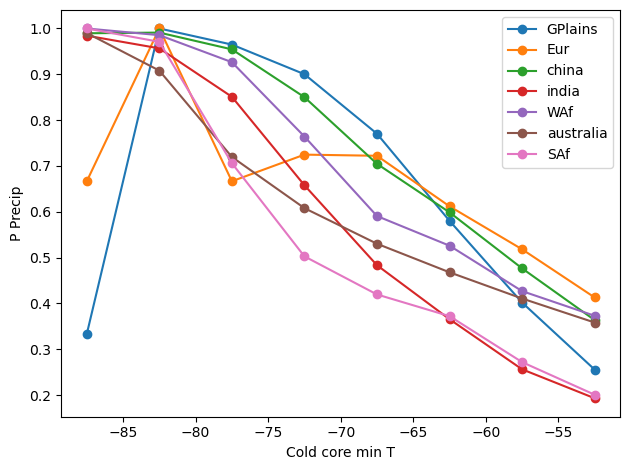

In [21]:
ax = f.add_subplot(111)
for ids, regs in enumerate(dics.keys()):
    outdic = hist2d.var2_binning_threshold((dics[regs]['tmin']).values, (dics[regs]['precipitation_max']).values, np.arange(-90,-40,5), gt=8)
    plt.plot(outdic['xbins'], outdic['y'], '-o', label=regs)
   
    ax.set_ylim(0,1)
plt.ylabel('P Precip')
plt.xlabel('Cold core min T')
plt.legend()
plt.tight_layout()

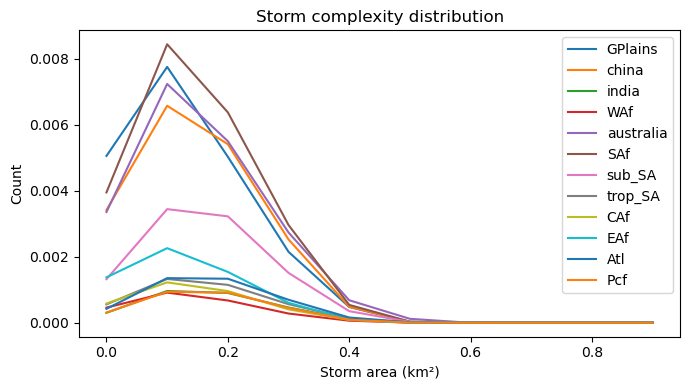

In [56]:
bins = np.linspace(0,1.1,11)

plt.figure(figsize=(7,4))
for ids, regs in enumerate(dics.keys()):
    hist, count, hbins = u_stats.histo_frequency(dics[regs]['shape_complexity'], bins=bins)

    #ipdb.set_trace()
    xbins = hbins[0:-1] + (hbins[1::]-hbins[0:-1])/2

    plt.plot(np.arange(0,1,0.1), hist/np.sum(count), label=regs)
    
plt.legend()

plt.xlabel("Storm area (km²)")
plt.ylabel("Count")
plt.title("Storm complexity distribution")
plt.tight_layout()
plt.show()

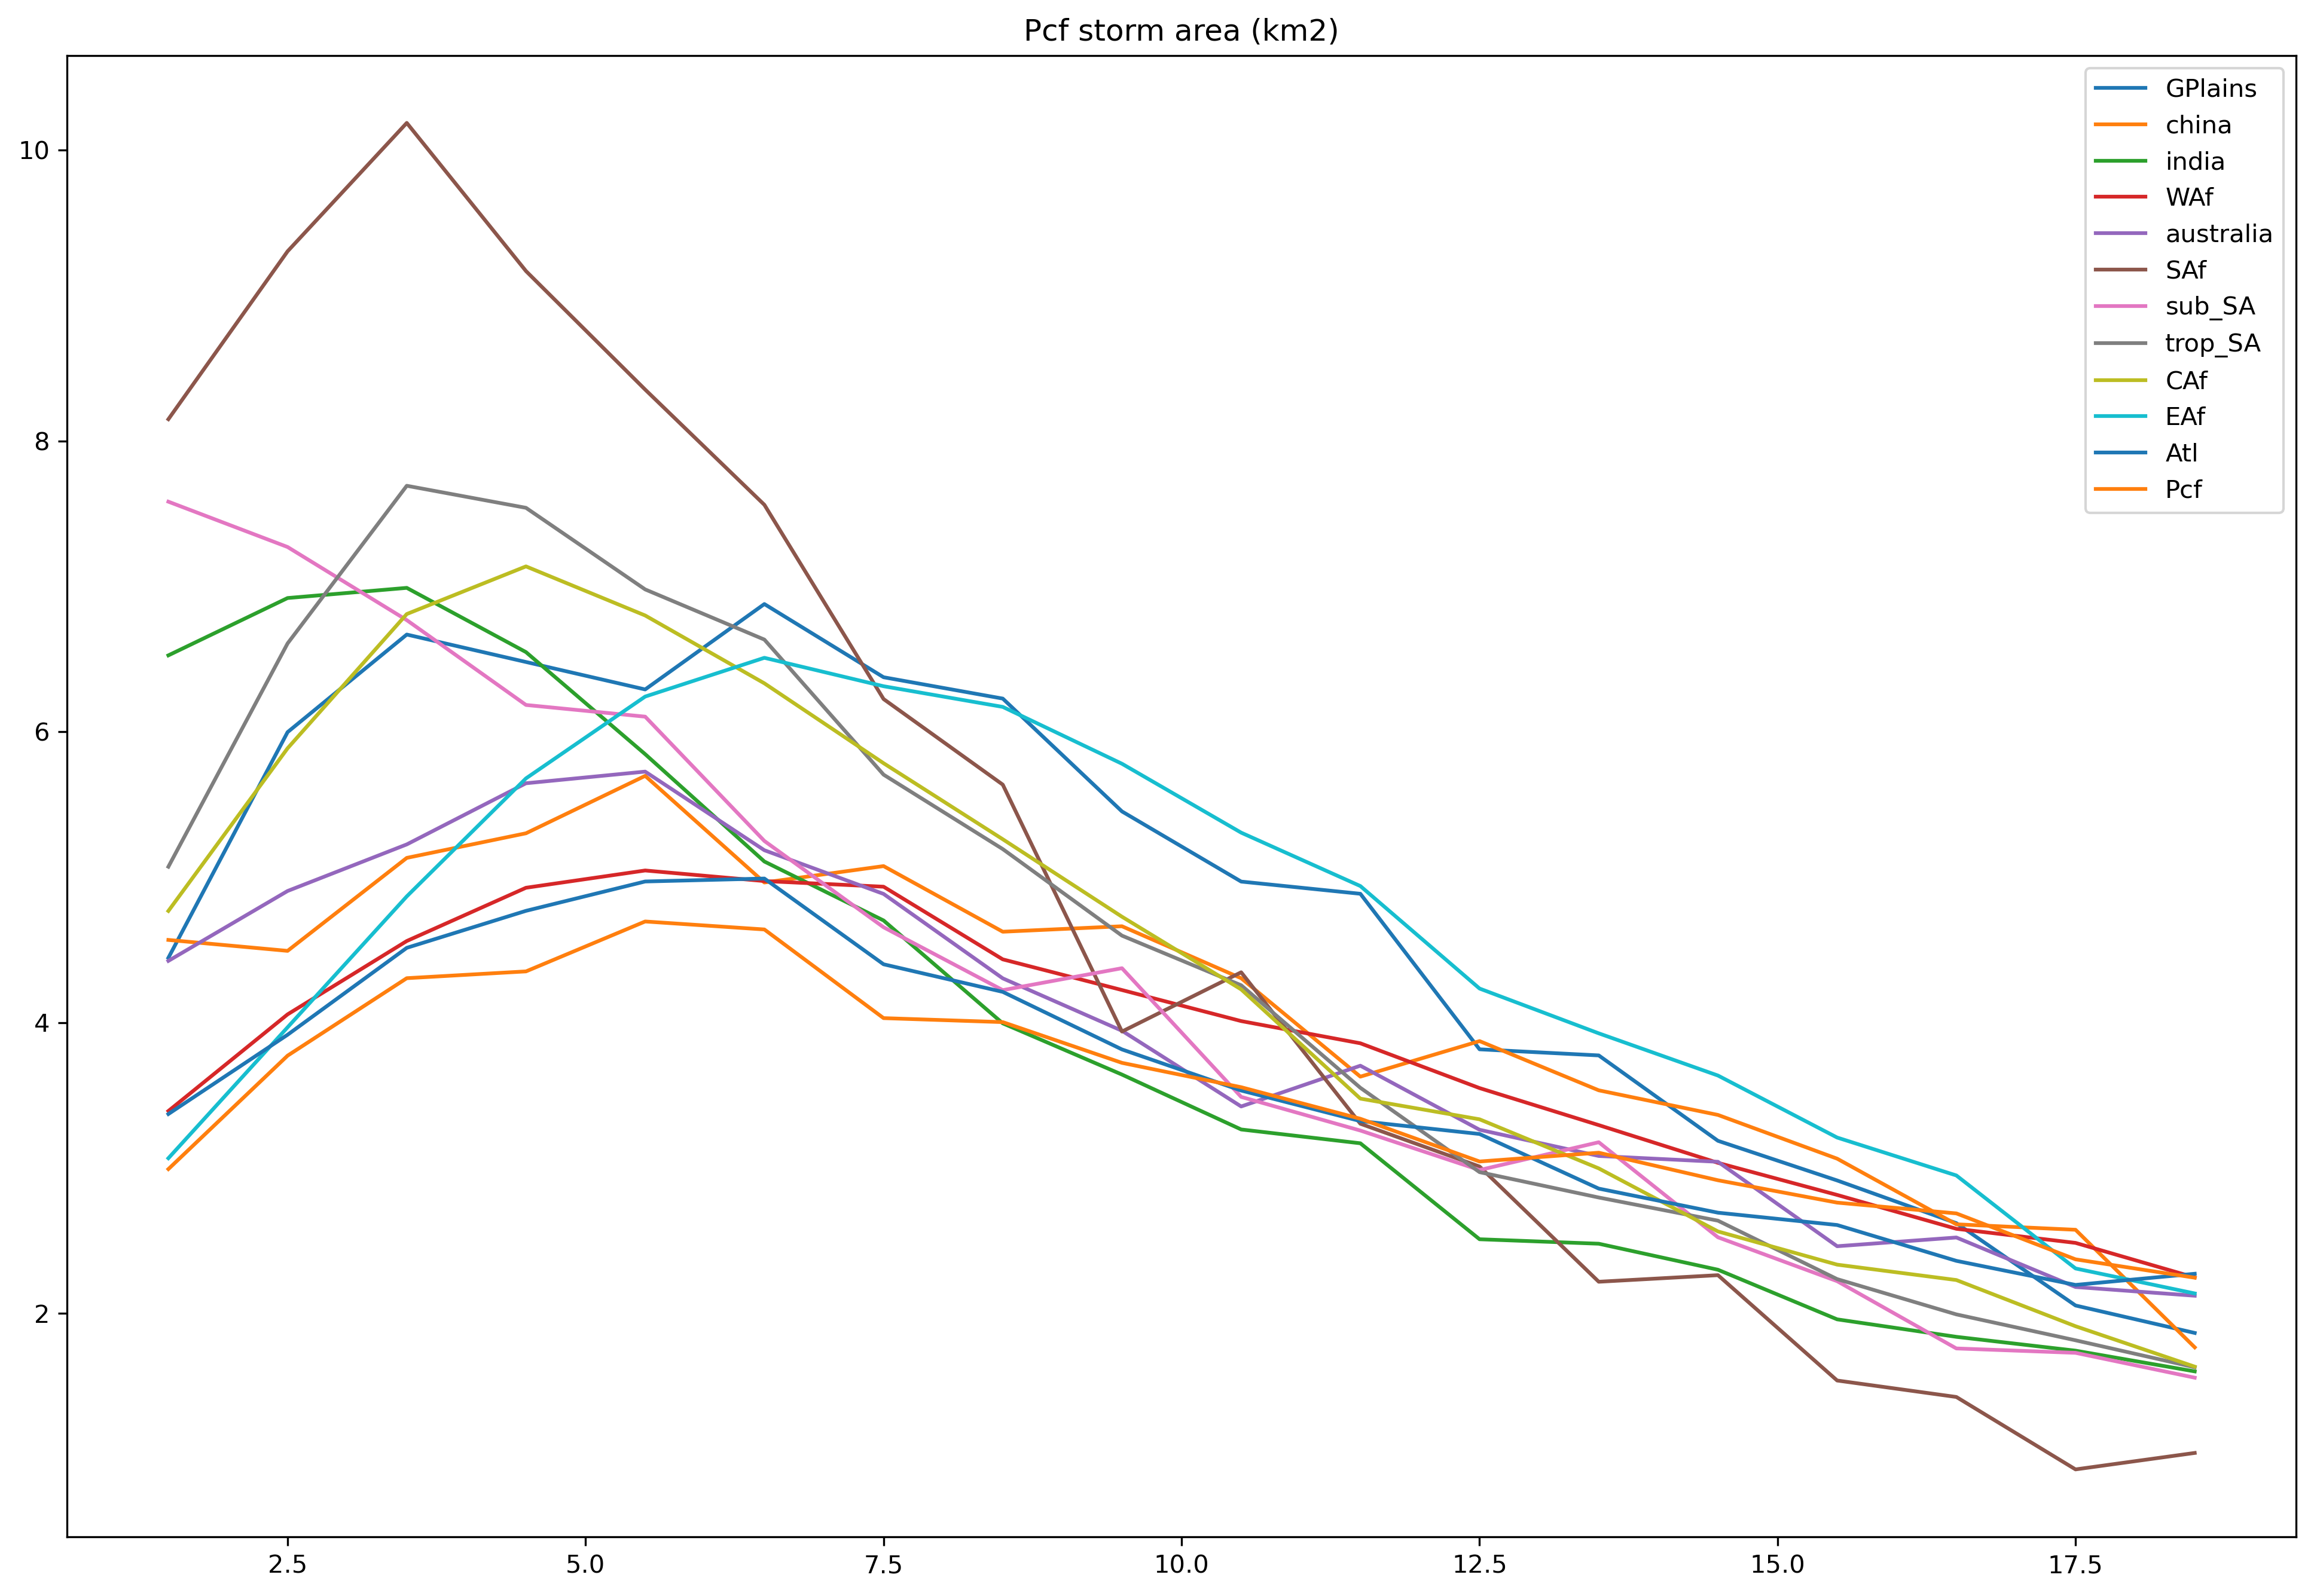

In [62]:
f= plt.figure(figsize=(13,9), dpi=300)

ax = f.add_subplot(111)
for ids, regs in enumerate(dics.keys()):

    pick = dics[regs]
    pick = pick[pick['shape_complexity']<0.5]
    
    hist_freq, hist_count, bin_edge = u_stats.histo_frequency(pick['precipitation_max'], bins=np.arange(1,20,1))
    mid_bin = bin_edge[0:-1] + (bin_edge[1::]-bin_edge[0:-1])/2
    ax.plot(mid_bin,hist_freq, label= regs)

plt.legend()
ax.set_title(regs+' storm area (km2)')

plt.tight_layout()

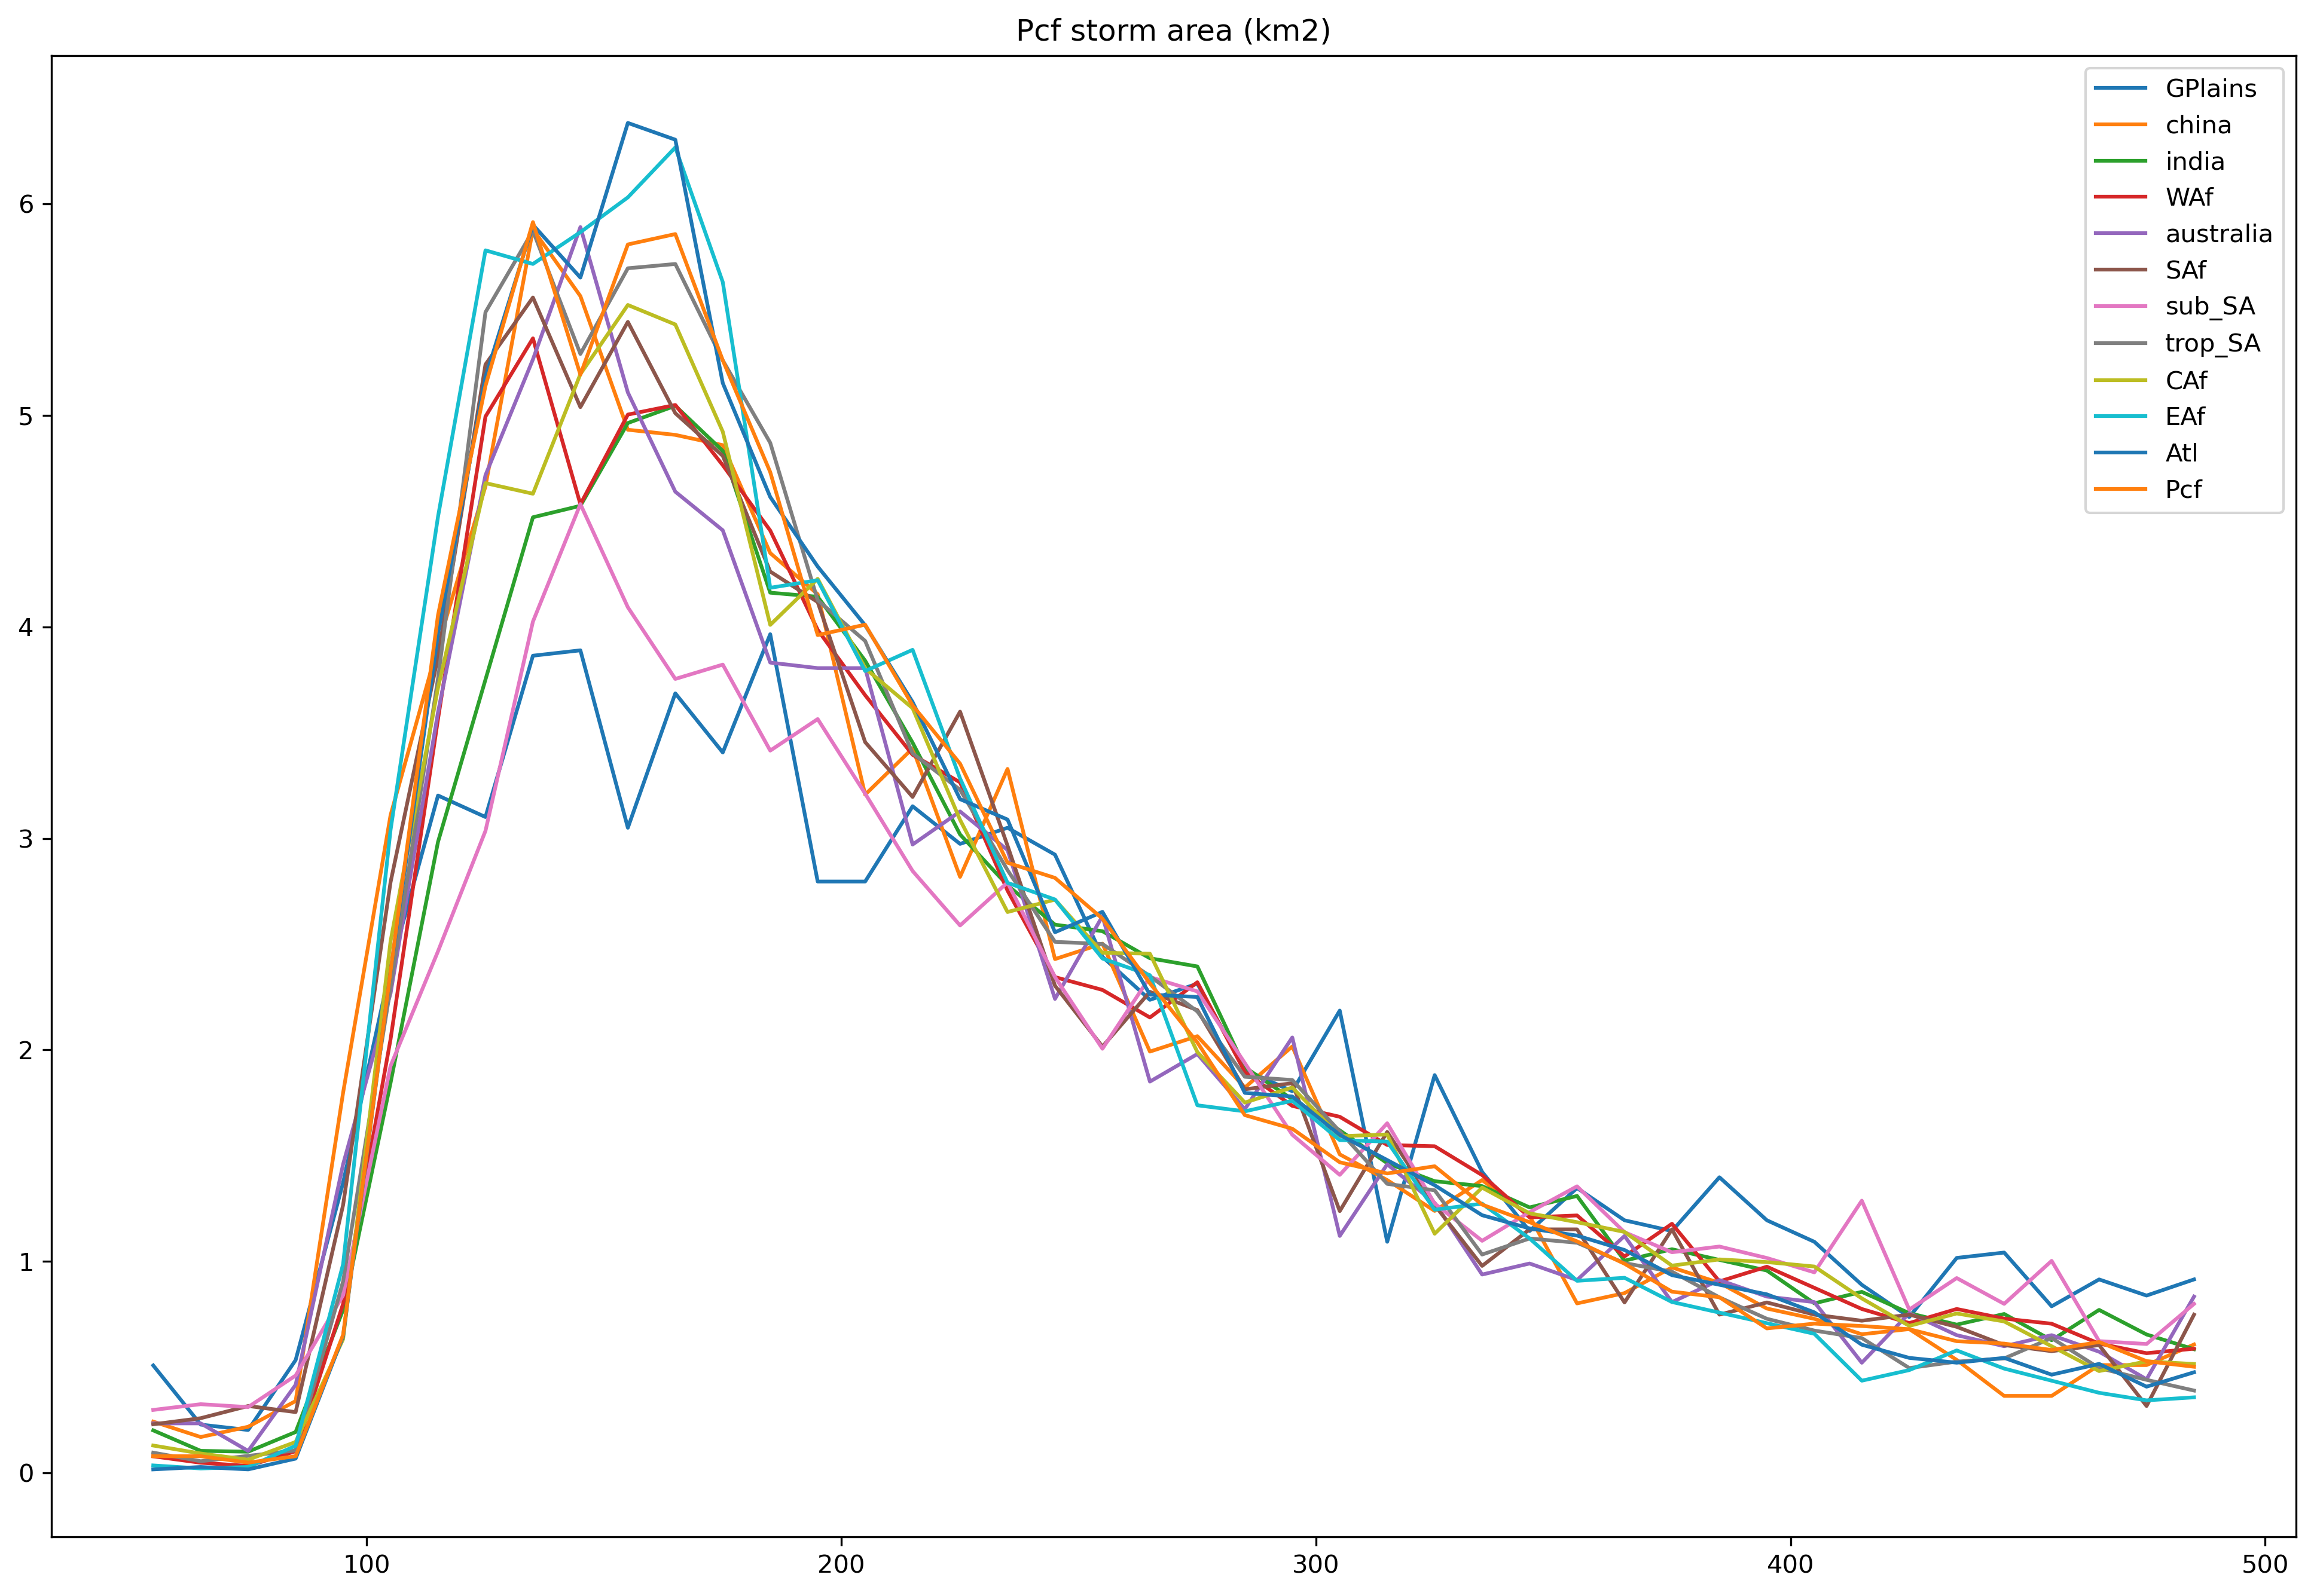

In [66]:
f= plt.figure(figsize=(13,9), dpi=300)

ax = f.add_subplot(111)
for ids, regs in enumerate(dics.keys()):

    pick = dics[regs]
    pick = pick[pick['shape_complexity']<0.3]
    
    hist_freq, hist_count, bin_edge = u_stats.histo_frequency(pick['major_axis_km'], bins=np.arange(50,500,10))
    mid_bin = bin_edge[0:-1] + (bin_edge[1::]-bin_edge[0:-1])/2
    ax.plot(mid_bin,hist_freq, label= regs)

plt.legend()
ax.set_title(regs+' storm area (km2)')

plt.tight_layout()

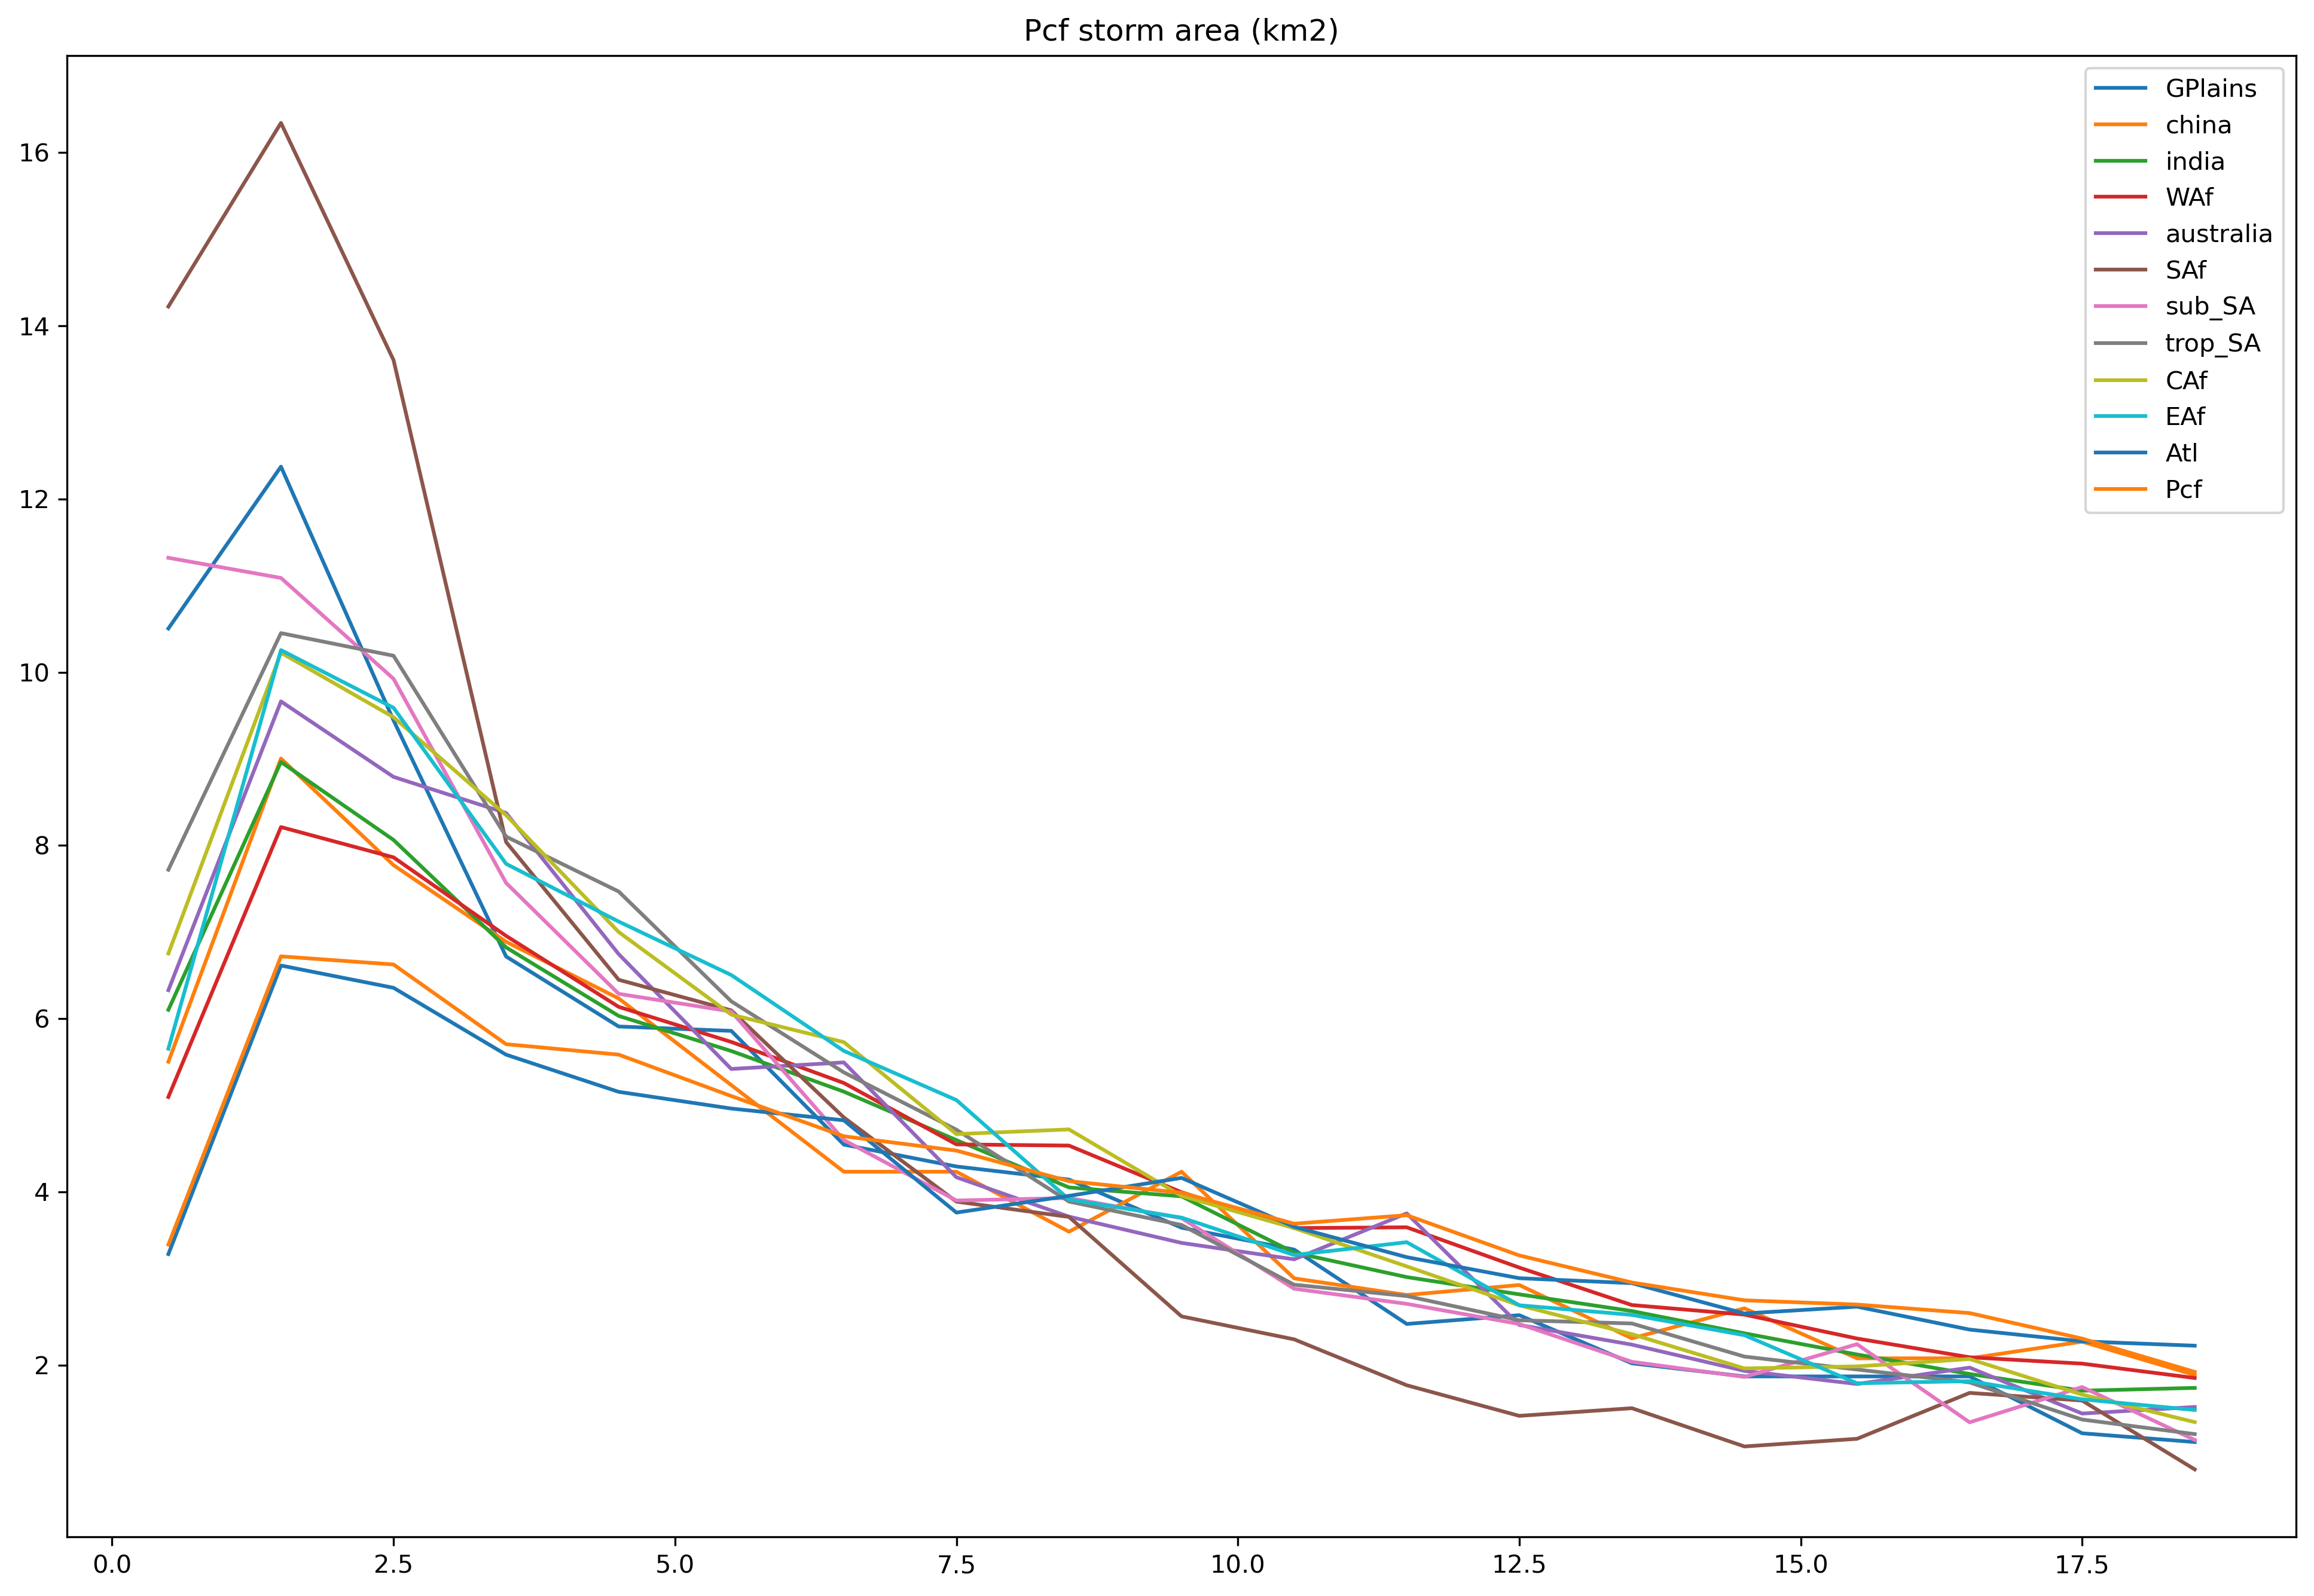

In [77]:
f= plt.figure(figsize=(13,9), dpi=300)

ax = f.add_subplot(111)
for ids, regs in enumerate(dics.keys()):

    pick = dics[regs]
    pick = pick[pick['precipitation_max']>=10]
    
    hist_freq, hist_count, bin_edge = u_stats.histo_frequency(pick['precipitation_area10mm']/pick['precipitation_area1mm']*100, bins=np.arange(0,20,1))
    mid_bin = bin_edge[0:-1] + (bin_edge[1::]-bin_edge[0:-1])/2
    ax.plot(mid_bin,hist_freq, label= regs)

plt.legend()
ax.set_title(regs+' storm area (km2)')

plt.tight_layout()